## 1. Import Libraries and Load Cleaned Data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler, OrdinalEncoder,StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [26]:
df = pd.read_csv('dataset/forestfires_CLEANING.csv')
df_x = df.drop(columns='area')
df_y = df['area']

In [27]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 240 samples
Test set: 60 samples


## 2. Feature Scaling

In [28]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]   
)

## 3.Pipeline All Models Regression

In [29]:
n = 15
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=0.1))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42))
    ]),
    
    'Neural Network (MLP)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', MLPRegressor(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',alpha=0.1,max_iter=2000, random_state=42))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [30]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: Neural Network (MLP)

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
2,Lasso Regression,-0.0664,2.7539,11.4757,3.3876
1,Ridge Regression,-0.0868,2.7547,11.6946,3.4197
0,Linear Regression,-0.0905,2.7561,11.7349,3.4256
3,Random Forest Regressor,-0.1794,2.9507,12.6911,3.5625
5,XGBoost Regressor,-0.2820,3.0564,13.7957,3.7143
6,Neural Network (MLP),-0.4869,3.1385,16.0000,4.0000
4,Gradient Boosting Regressor,-0.5158,3.2561,16.3110,4.0387


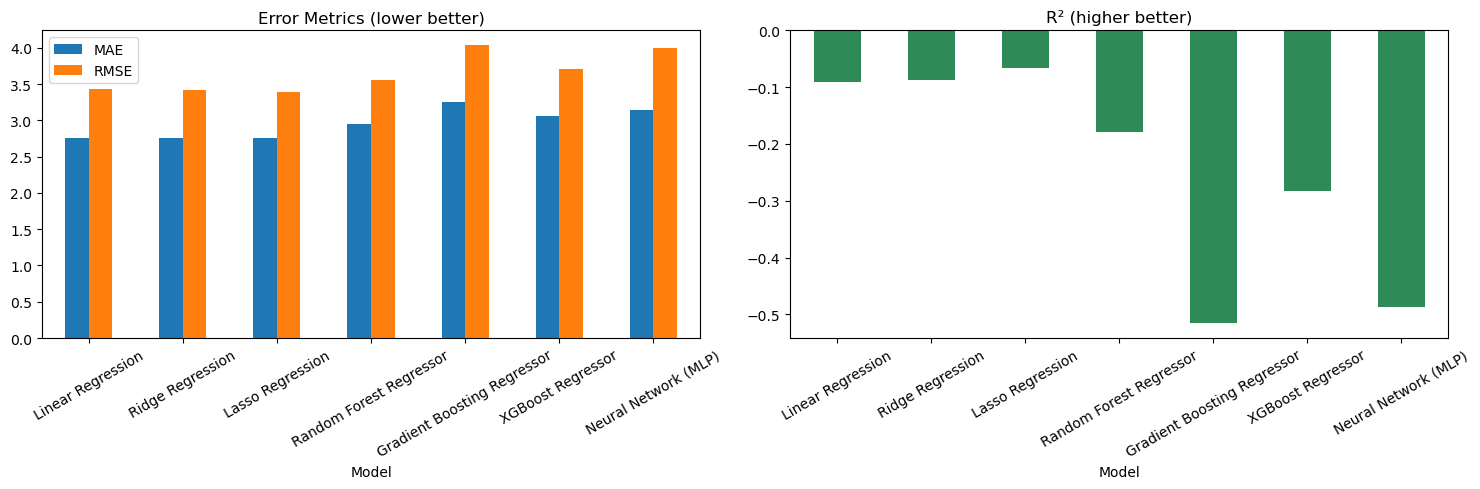

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [32]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=10, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 10-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: Neural Network (MLP)

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
4,Gradient Boosting Regressor,-0.352723,2.827533,15.539279,3.941989
2,Lasso Regression,-0.497937,3.032627,16.067382,4.008414
1,Ridge Regression,-0.498828,3.013383,16.002904,4.000363
0,Linear Regression,-0.498987,3.012315,16.011930,4.001491
3,Random Forest Regressor,-0.537969,3.004804,16.065972,4.008238
5,XGBoost Regressor,-0.596900,2.944786,16.316905,4.039419
6,Neural Network (MLP),-1.960181,3.479237,23.275292,4.824447


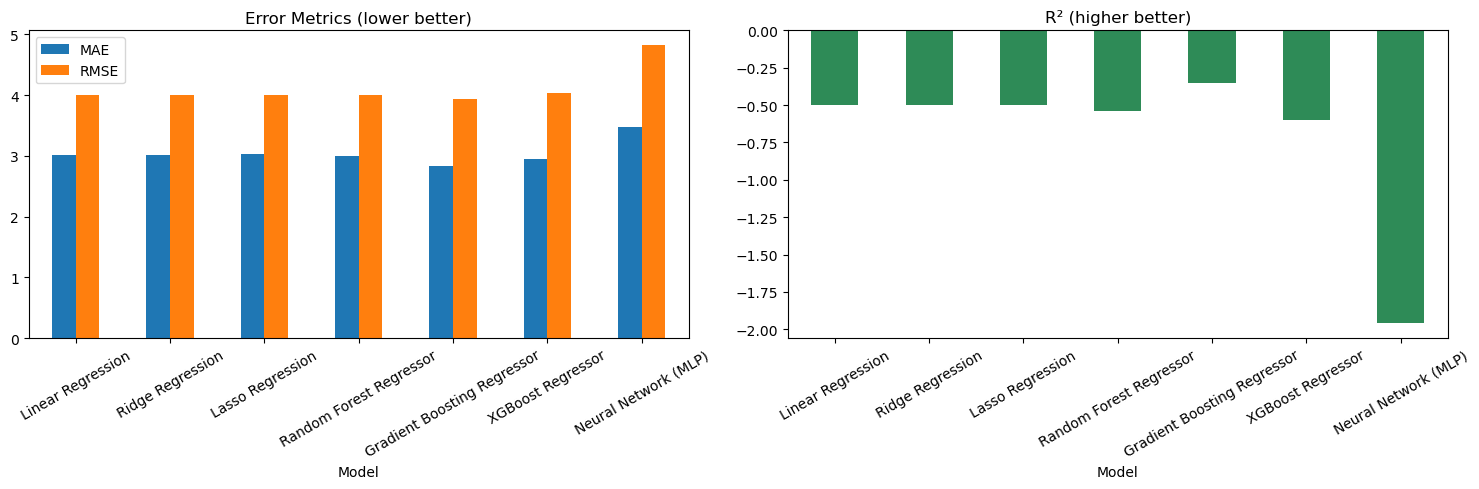

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
